In [1]:
import cv2
import numpy as np
from show_img import show_img

red = (0, 0, 255)
green = (0, 255, 0)
blue = (255, 0, 0)
black = (0, 0, 0)

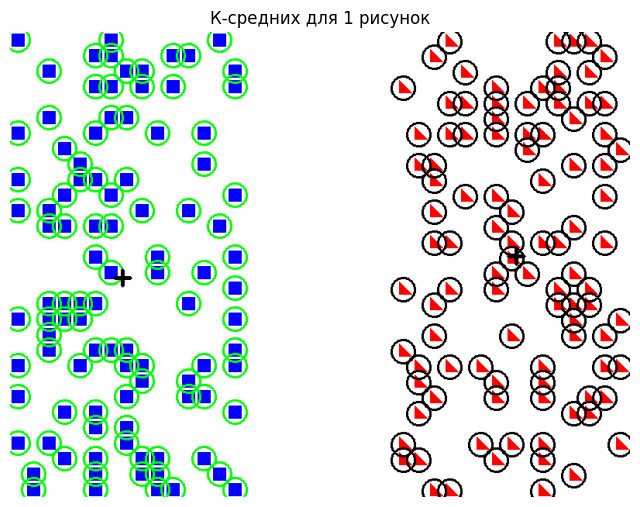

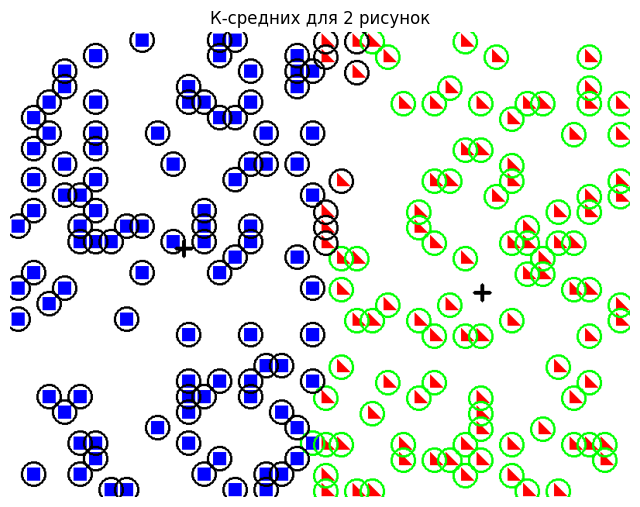

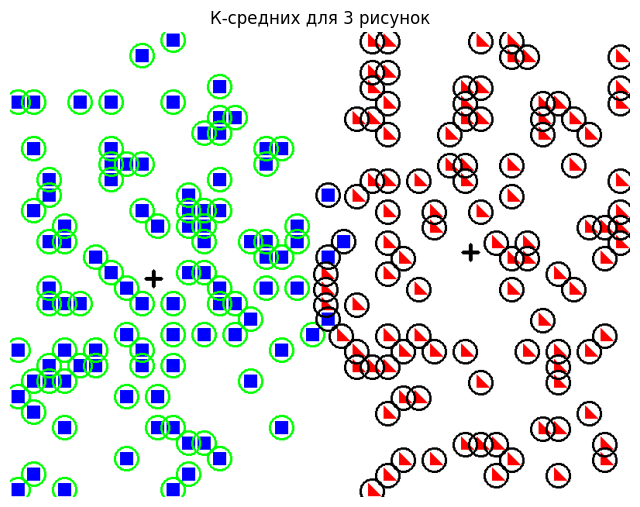

In [2]:
def kmeans_on_image(img, title):
    img_display = img.copy()
    img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_thres = cv2.threshold(img_grayscale, 240, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(img_thres, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    points = []
    for contour in contours:
        M = cv2.moments(contour)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            points.append([cx, cy])
            
    Z = np.float32(points)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0) 
    _, labels, centers = cv2.kmeans(Z, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    cluster_0 = Z[labels.ravel() == 0]
    cluster_1 = Z[labels.ravel() == 1]
    
    for pt in cluster_0:
        cv2.circle(img_display, (int(pt[0]), int(pt[1])), 15, green, 2)
    for pt in cluster_1:
        cv2.circle(img_display, (int(pt[0]), int(pt[1])), 15, black, 2)
    for c in centers:
        cv2.drawMarker(img_display, (int(c[0]), int(c[1])), (0, 0, 0), cv2.MARKER_CROSS, 20, 3)

    show_img(img_display, title=f"К-средних для {title}", size=8)

kmeans_on_image(cv2.imread("lab10_img1_easy.png"), "1 рисунок")
kmeans_on_image(cv2.imread("lab10_img2_close.png"), "2 рисунок")
kmeans_on_image(cv2.imread("lab10_img3_overlap.png"), "3 рисунок")

In [3]:
def get_trained_data(img):
    train_data = []
    class_labels = []
    
    mask_blue = cv2.inRange(img, np.array([250, 0, 0]), np.array([255, 10, 10]))
    contours_blue, _ = cv2.findContours(mask_blue, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for contour in contours_blue:
        M = cv2.moments(contour)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            train_data.append([cx, cy])
            class_labels.append([0])
            
    mask_red = cv2.inRange(img, np.array([0, 0, 250]), np.array([10, 10, 255]))
    contours_red, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for contour in contours_red:
        M = cv2.moments(contour)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            train_data.append([cx, cy])
            class_labels.append([1])

    train_data = np.float32(train_data)
    class_labels = np.float32(class_labels)

    return train_data, class_labels

KNN для рисунка 1 рисунок
Точка (150, 150), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[1600. 1600. 2000. 2000. 2000.]]
Точка (150, 300), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 500. 1700. 1700. 1700. 2900.]]
Точка (200, 450), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 900.  900. 1300. 1300. 2900.]]
Точка (650, 150), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 293.  613.  853. 1693. 1973.]]
Точка (600, 300), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 873. 1753. 1873. 2113. 2273.]]
Точка (650, 450), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 533. 1013. 1373. 1693. 1853.]]
Точка (400, 150), соседи: [0. 1. 1. 1. 0.], класс: Triangle, расстояние до соседних: [[15700. 16453. 16613. 17533. 18500.]]
Точка (400, 300), соседи: [0. 1. 0. 0. 0.], класс: Square, расстояние до соседних: [[12200. 12473. 13000. 17000. 19400.]]
Точка (400, 450), со

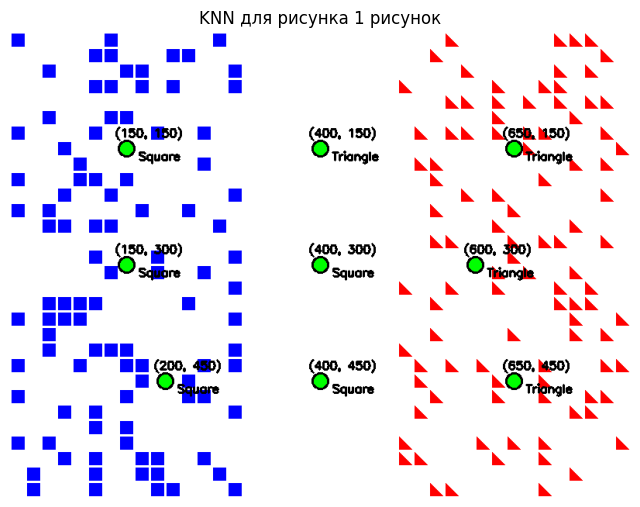

KNN для рисунка 2 рисунок
Точка (150, 150), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[1600. 2000. 2000. 3200. 4000.]]
Точка (150, 300), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 500. 1300. 2500. 2500. 2900.]]
Точка (200, 450), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 900. 1300. 2500. 2900. 3700.]]
Точка (650, 150), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 493. 1453. 1773. 1853. 3653.]]
Точка (600, 300), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 233. 2993. 3593. 3793. 4633.]]
Точка (650, 450), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[2333. 3573. 3613. 5213. 5213.]]
Точка (390, 200), соседи: [0. 0. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 100. 1300. 1313. 1433. 2993.]]
Точка (400, 350), соседи: [0. 1. 0. 1. 1.], класс: Triangle, расстояние до соседних: [[ 500. 1053. 1700. 2693. 4093.]]
Точка (410, 500), соседи: [1

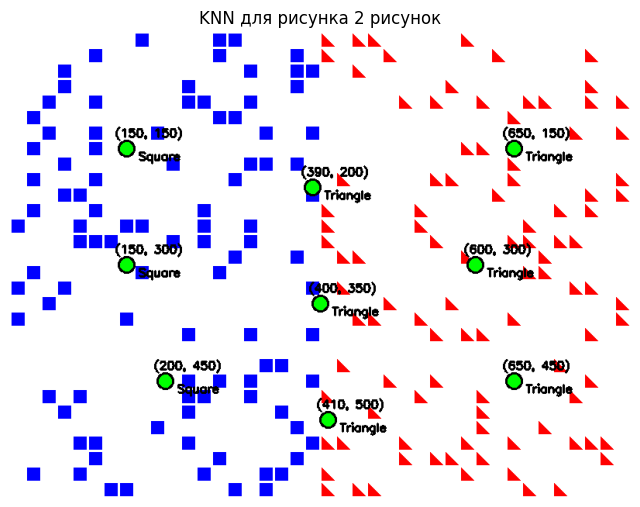

KNN для рисунка 3 рисунок
Точка (100, 150), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 900. 1300. 2500. 2900. 3700.]]
Точка (100, 450), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 500.  500.  900. 1700. 2500.]]
Точка (200, 300), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[1000. 2600. 2600. 2600. 3400.]]
Точка (700, 150), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[ 493. 1213. 1613. 2173. 2533.]]
Точка (700, 450), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[  53.  373. 1493. 2533. 3653.]]
Точка (600, 300), соседи: [1. 1. 1. 1. 1.], класс: Triangle, расстояние до соседних: [[1513. 2273. 3233. 4553. 4673.]]
Точка (390, 250), соседи: [0. 0. 0. 0. 0.], класс: Square, расстояние до соседних: [[ 400.  800. 2000. 2000. 2000.]]
Точка (400, 300), соседи: [1. 0. 1. 0. 0.], класс: Square, расстояние до соседних: [[ 193.  200. 1073. 1800. 1800.]]
Точка (410, 350), соседи: [1. 1.

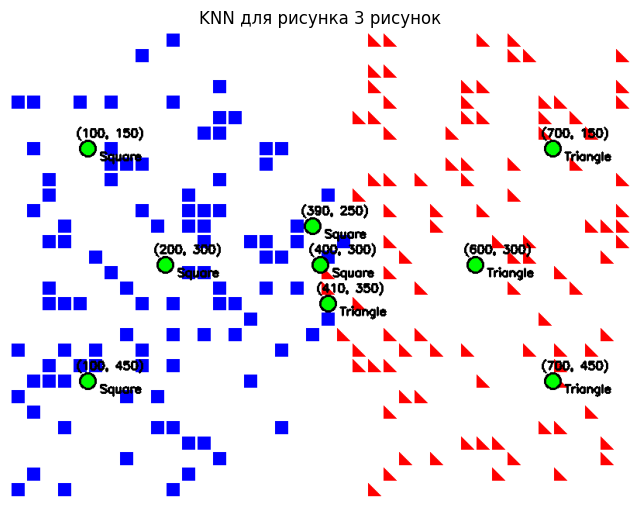

In [4]:
def knn_on_image(img, title, test_points):
    img_display = img.copy()
    
    train_data, class_labels = get_trained_data(img)

    knn = cv2.ml.KNearest_create()
    knn.train(train_data, cv2.ml.ROW_SAMPLE, class_labels)

    print(f"KNN для рисунка {title}")
    
    for pt in test_points:
        cv2.circle(img_display, pt, 10, green, -1)
        cv2.circle(img_display, pt, 10, black, 2)
        
        new_point = np.float32([[pt[0], pt[1]]])
        _, results, neighbours, dist = knn.findNearest(new_point, 5)
        
        predicted_class = int(results[0][0])
        if predicted_class == 0: class_name = "Square" 
        else: class_name = "Triangle"
        
        print(f"Точка {pt}, соседи: {neighbours[0]}, класс: {class_name}, расстояние до соседних: {dist}")
        
        cv2.putText(img_display, str(pt), (pt[0]-15, pt[1]-15), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, black, 2)
        cv2.putText(img_display, class_name, (pt[0]+15, pt[1]+15), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, black, 2)

    show_img(img_display,title=f"KNN для рисунка {title}", size=8)

points_img1 = [(150, 150), (150, 300), (200, 450),
               (650, 150), (600, 300), (650, 450),
               (400, 150), (400, 300), (400, 450)]
knn_on_image(cv2.imread("lab10_img1_easy.png"), "1 рисунок", points_img1)

points_img2 = [(150, 150), (150, 300), (200, 450),
               (650, 150), (600, 300), (650, 450),
               (390, 200), (400, 350), (410, 500)]
knn_on_image(cv2.imread("lab10_img2_close.png"), "2 рисунок", points_img2)

points_img3 = [(100, 150), (100, 450), (200, 300),
               (700, 150), (700, 450), (600, 300),
               (390, 250), (400, 300), (410, 350)]
knn_on_image(cv2.imread("lab10_img3_overlap.png"), "3 рисунок", points_img3)